# 02. Cleaning & Feature Engineering

Output: a model-ready `train_clean.csv` saved to `data/processed/`.

In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path("..").resolve() / "src"))
import data_prep as dp
import features as feat

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)

In [7]:
train = dp.load_data(RAW_DIR / "train.csv")

print(f"train: {train.shape[0]:,} rows x {train.shape[1]} columns")

train: 137 rows x 43 columns


## 1. Data quality recap



In [8]:
missing = dp.missing_value_summary(train)
dupes = dp.duplicate_summary(train)

assert missing.empty, "Unexpected missing values — investigate before proceeding."
assert dupes["full_row_duplicates"] == 0, "Unexpected duplicate rows — investigate before proceeding."

## 2. Target: log-transform `revenue`

The 8 high-revenue outliers found in EDA are real İstanbul/İzmir restaurants, not data errors,
so they're kept. Instead of removing them, `log1p(revenue)` is added as the modeling target.

In [9]:
train["log_revenue"] = np.log1p(train["revenue"])

print(f"Skew (raw revenue):   {train['revenue'].skew():.3f}")
print(f"Skew (log_revenue):   {train['log_revenue'].skew():.3f}")

Skew (raw revenue):   2.793
Skew (log_revenue):   0.307


## 3. Date features from `Open Date`

Two kinds of signal, kept separate:

- **Age** (`age_days`, `age_months`): elapsed time relative to the TFI competition's launch
  date (2015-01-01). `age_months` is the same idea at a coarser grain.
- **Calendar components** (`open_year`, `open_month`, `open_day`, `open_week`): *when on the
  calendar* a restaurant opened, which age alone can't capture — e.g. a possible seasonal
  effect from opening in December vs. June. `open_month`/`open_week` are left as raw integers
  for now (not cyclically encoded), which is a modeling-stage concern to revisit if seasonality
  turns out to matter.

In [10]:
train["age_days"] = feat.compute_age_days(train)
train["age_months"] = feat.compute_age_months(train)
train[["open_year", "open_month", "open_day", "open_week"]] = feat.extract_date_parts(train)

date_feature_cols = ["age_days", "age_months", "open_year", "open_month", "open_day", "open_week"]
train[date_feature_cols].describe()

,age_days,age_months,open_year,open_month,open_day,open_week
count,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,2111.262774,68.890511,2008.678832,7.058394,14.671533,28.357664
std,1471.257507,48.294087,4.027359,3.590769,8.899859,15.685670
min,341.000000,11.000000,1996.000000,1.000000,1.000000,1.000000
25%,1107.000000,36.000000,2007.000000,4.000000,8.000000,14.000000
50%,1773.000000,58.000000,2010.000000,8.000000,14.000000,32.000000
75%,2588.000000,85.000000,2011.000000,10.000000,23.000000,41.000000
max,6812.000000,223.000000,2014.000000,12.000000,31.000000,52.000000


## 4. Categorical encoding: `City`, `City Group`, `Type`

- `City` (34 unique values, several singletons across 137 rows) is too high-cardinality to
  one-hot encode safely at this sample size — but dropping it outright throws away real
  information (İstanbul's 50 restaurants is a different market than a city with one). Instead
  it's **frequency-encoded**: each row gets the share of training restaurants in its city, as a
  single numeric `city_freq` column instead of 33 dummy columns. `City Group` is still kept and
  one-hot encoded too — it captures the coarser Big Cities vs. Other split.
- `Type` has a singleton `DT` category. Left as-is, a train/validation split could easily put
  that one row on the wrong side and produce an unseen category. It's bucketed into `Other`
  before one-hot encoding.

In [11]:
train["city_freq"] = feat.frequency_encode(train["City"])

train[["City", "city_freq"]].sort_values("city_freq", ascending=False).drop_duplicates().head(10)

,City,city_freq
0,İstanbul,0.364964
109,Ankara,0.138686
18,İzmir,0.065693
53,Samsun,0.036496
127,Bursa,0.036496
88,Antalya,0.029197
30,Sakarya,0.029197
103,Tekirdağ,0.021898
104,Adana,0.021898
114,Eskişehir,0.021898


In [12]:
train["type_bucketed"] = feat.bucket_rare_categories(train["Type"], min_count=5)

print("Before bucketing:")
print(train["Type"].value_counts())
print("\nAfter bucketing:")
print(train["type_bucketed"].value_counts())

Before bucketing:
Type
FC    76
IL    60
DT     1
Name: count, dtype: int64

After bucketing:
type_bucketed
FC       76
IL       60
Other     1
Name: count, dtype: int64


In [13]:
train["city_group"] = train["City Group"].rename("city_group")

cat_dummies = pd.get_dummies(
    train[["city_group", "type_bucketed"]], prefix=["city_group", "type"], drop_first=True
)

cat_dummies.head()

,city_group_Other,type_IL,type_Other
0,False,True,False
1,False,False,False
2,True,True,False
3,True,True,False
4,True,True,False


## 5. `P1`-`P37`: kept as-is, plus sparse-block flags

EDA's sparsity check (`>=50%` zeros) also picked out exactly three *consecutive* runs of the
schema: `P14`-`P18`, `P24`-`P27`, `P30`-`P37` (17 columns total). 

In [14]:
all_zero_flags = feat.add_all_zero_flags(train)
train[all_zero_flags.columns] = all_zero_flags

for name, cols in feat.SPARSE_P_GROUPS.items():
    print(f"{name} ({cols[0]}-{cols[-1]}): {train[name].sum()} of {len(train)} rows all-zero")

all_zero_flags.head()

all_zero (P14-P37): 88 of 137 rows all-zero


,all_zero
0,0
1,1
2,1
3,0
4,0


## 6. Assemble final feature set

Combine `Id`, the engineered/encoded features, `P1`-`P37` plus the `all_zero` block
flags, and both the raw and log-transformed target into a single model-ready table.
`Open Date`, `City`, `City Group`, `Type`, and `type_bucketed` are dropped now that they've
been superseded by the date features, `city_freq`, and the one-hot encoded columns.

In [15]:
train_clean = pd.concat(
    [
        train[["Id"] + date_feature_cols + ["city_freq"]],
        cat_dummies,
        train[dp.P_COLUMNS],
        train[list(feat.SPARSE_P_GROUPS.keys())],
        train[["revenue", "log_revenue"]],
    ],
    axis=1,
)

print(f"train_clean: {train_clean.shape[0]:,} rows x {train_clean.shape[1]} columns")
train_clean.head()

train_clean: 137 rows x 51 columns


,Id,age_days,age_months,open_year,open_month,open_day,open_week,city_freq,city_group_Other,type_IL,type_Other,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,...,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,all_zero,revenue,log_revenue
0,0,5647,185,1999,7,17,28,0.364964,False,True,False,4,5.0,4.0,4.0,2,2,5,4,5,5,3,5,5.0,1,...,2,2,4,5,4,1,3,3,1,1,1.0,4.0,2.0,3.0,5,3,4,5,5,4,3,4,0,5653753.0,15.547830
1,1,2513,82,2008,2,14,7,0.138686,False,False,False,4,5.0,4.0,4.0,1,2,5,5,5,5,1,5,5.0,0,...,0,0,0,3,2,1,3,2,0,0,0.0,0.0,3.0,3.0,0,0,0,0,0,0,0,0,1,6923131.0,15.750379
2,2,663,21,2013,3,9,10,0.021898,True,True,False,2,4.0,2.0,5.0,2,3,5,5,5,5,2,5,5.0,0,...,0,0,0,1,1,1,1,1,0,0,0.0,0.0,1.0,3.0,0,0,0,0,0,0,0,0,1,2055379.0,14.535971
3,3,1064,34,2012,2,2,5,0.007299,True,True,False,6,4.5,6.0,6.0,4,4,10,8,10,10,8,10,7.5,6,...,9,3,12,20,12,6,1,10,2,2,2.5,2.5,2.5,7.5,25,12,10,6,18,12,12,6,0,2675511.0,14.799651
4,4,2063,67,2009,5,9,19,0.007299,True,True,False,3,4.0,3.0,4.0,2,2,5,5,5,5,2,5,5.0,2,...,2,1,4,2,2,1,2,1,2,3,3.0,5.0,1.0,3.0,5,1,3,2,3,4,3,3,0,4316715.0,15.278005


In [16]:
out_path = feat.save_processed(train_clean, "train_clean.csv", PROCESSED_DIR)
print(f"Saved to {out_path}")

Saved to ../data/processed/train_clean.csv


## Summary

1. No missing values or duplicates — confirmed again on this extract.
2. `log_revenue` added as the modeling target; raw `revenue` kept
   alongside it for reference/reporting.
3. Six date features derived from `Open Date`: `age_days`/`age_months` (elapsed time vs.
   2015-01-01) and `open_year`/`open_month`/`open_day`/`open_week` (calendar components, for
   any seasonal effect age alone wouldn't catch).
4. `City` frequency-encoded (`city_freq`) rather than dropped — keeps a signal from all 34
   cities in one numeric column instead of discarding it for being too high-cardinality to
   one-hot encode. `City Group` and a rare-category-bucketed `Type` are one-hot encoded.
5. All 37 `P` columns kept unchanged; three binary `all_zero_g1/g2/g3` flags added for the
   sparse `P14`-`P18`/`P24`-`P27`/`P30`-`P37` blocks found in EDA. Correlated blocks otherwise
   left for the modeling notebook to handle via regularization/PCA/feature selection.
6. Result saved to `data/processed/train_clean.csv`, ready for `03_modeling`.

## 7. Correlation with the target

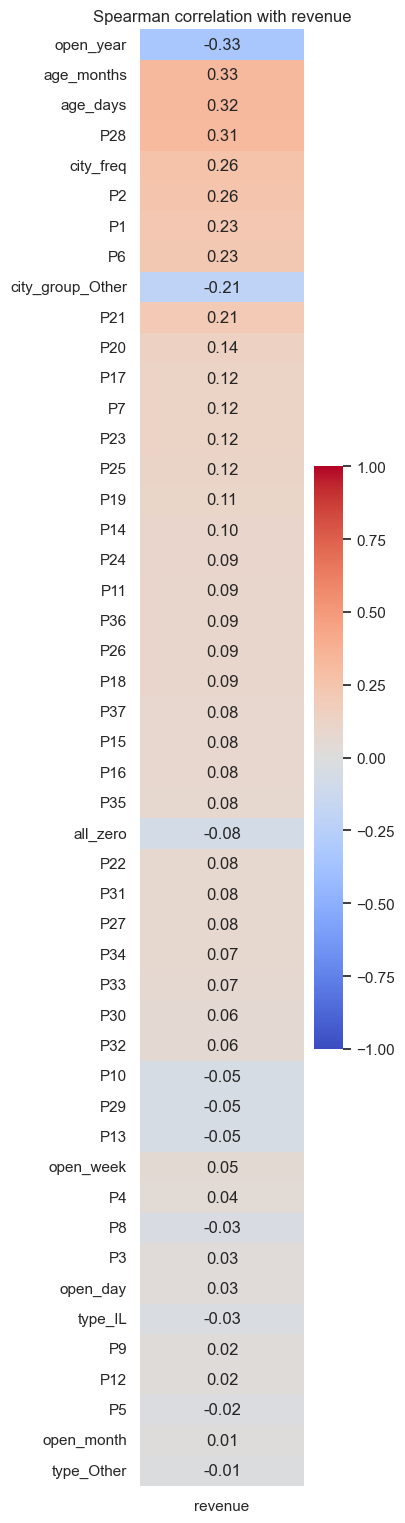

open_year          -0.330274
age_months          0.325806
age_days            0.324933
P28                 0.312546
city_freq           0.260181
P2                  0.256816
P1                  0.231995
P6                  0.225137
city_group_Other   -0.209481
P21                 0.205224
dtype: float64

In [17]:
target_corr = (
    train_clean.drop(columns=["Id", "revenue", "log_revenue"])
    .corrwith(train_clean["revenue"], method="spearman")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(4, 0.3 * len(target_corr) + 1))
sns.heatmap(
    target_corr.to_frame("revenue"), annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, cbar_kws={"shrink": 0.4}, ax=ax,
)
ax.set_title("Spearman correlation with revenue")
fig.tight_layout()
dp.save_fig(fig, "train_clean_correlation_with_revenue.png", FIGURES_DIR)
plt.show()

target_corr.head(10)

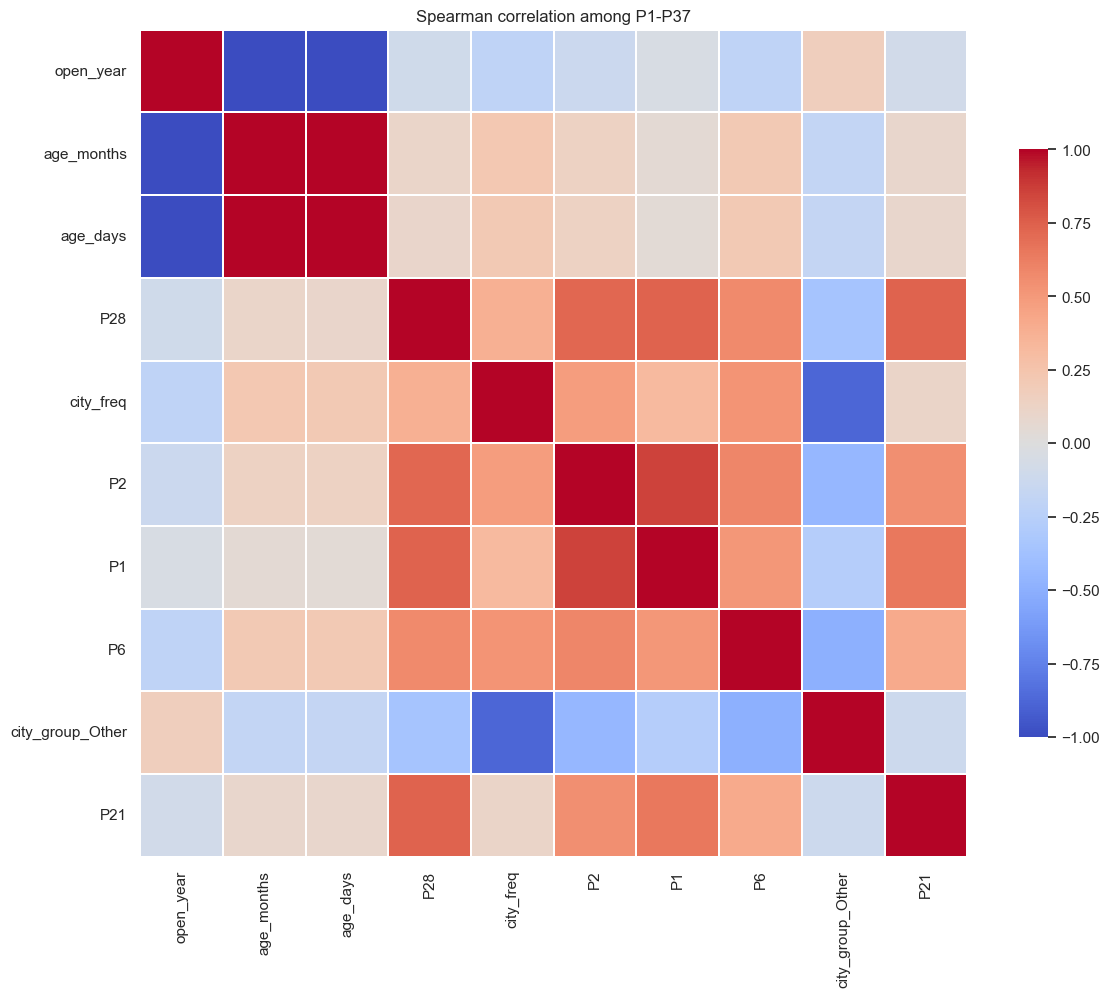

In [18]:
p_corr_matrix = train_clean[["open_year", "age_months", "age_days", "P28", "city_freq", "P2", "P1", "P6", "city_group_Other", "P21"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    p_corr_matrix, ax=ax, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.2, cbar_kws={"shrink": 0.7},
)
ax.set_title("Spearman correlation among P1-P37")
fig.tight_layout()
dp.save_fig(fig, "p_variables_correlation_heatmap.png", FIGURES_DIR)
plt.show()